# Taller: Auditoría de Desempeño para Negocios Digitales:

# Nombre: Gabriel Quilachamin

# Fecha: 19/06/2026

## Parte 1: Análisis de datos sintéticos

En esta parte vamos a analizar un dataset de transacciones y determinar si la estrategia de M-Commerce (App Móvil) es más rentable que el E-Commerce tradicional (Web Desktop).

Vamos a generar una base de datos aleatoria, que simula la salida de un TPS.

In [5]:
import pandas as pd
import numpy as np

# Generar datos simulados
data = {
    'ID_Transaccion': range(1001, 1051),
    'Canal': np.random.choice(['Web Desktop', 'App Móvil'], 50, p=[0.4, 0.6]),
    'Metodo_Pago': np.random.choice(['Tarjeta Crédito', 'PayPal', 'Transferencia'], 50),
    'Total_Venta': np.random.randint(20, 500, 50), # Ventas entre $20 y $500
    'Categoria': np.random.choice(['Electrónica', 'Moda', 'Hogar'], 50)
}

df = pd.DataFrame(data)

df

,ID_Transaccion,Canal,Metodo_Pago,Total_Venta,Categoria
0,1001,App Móvil,Tarjeta Crédito,60,Electrónica
1,1002,Web Desktop,PayPal,214,Hogar
2,1003,App Móvil,PayPal,144,Hogar
3,1004,App Móvil,Transferencia,483,Moda
4,1005,App Móvil,Tarjeta Crédito,474,Hogar
5,1006,App Móvil,Tarjeta Crédito,417,Moda
6,1007,App Móvil,Transferencia,412,Electrónica
7,1008,Web Desktop,Transferencia,350,Hogar
8,1009,App Móvil,Tarjeta Crédito,281,Electrónica
9,1010,Web Desktop,PayPal,419,Moda


### ¿Qué preguntas deberíamos plantearnos para obtener las respuestas que buscamos?

Buscamos saber cuál de las dos estrategias (M-Commerce o E-Commerce) es la más rentable.

Vamos a crear 4 KPIs para un MIS que nos permitan responder esta pregunta.

### Preguntas Estratégicas y KPIs para Análisis de Rentabilidad

Para determinar si la estrategia de M-Commerce es financieramente superior al E-Commerce tradicional, debemos plantearnos las siguientes 4 preguntas clave con sus respectivos Indicadores Clave de Rendimiento (KPIs):

**1. ¿Qué plataforma genera el mayor volumen de ingresos brutos para el negocio?**
* **KPI 1: Ingreso Total Acumulado por Canal.** Es la suma de las ventas brutas (`Total_Venta`) agrupadas por `Canal`. Este indicador directo nos muestra qué plataforma inyecta más liquidez absoluta a la empresa.

**2. ¿En qué entorno digital los clientes tienen un mayor poder o intención de gasto por cada compra?**
* **KPI 2: Ticket Promedio de Venta por Canal.** Es el promedio aritmético de las compras (`Total_Venta`) dividido por `Canal`. Nos permite saber si, independientemente del volumen de usuarios, una plataforma motiva a gastar montos más altos por carrito.

**3. ¿Qué tipo de productos impulsan la rentabilidad en dispositivos móviles frente a los ordenadores de escritorio?**
* **KPI 3: Volumen de Ingresos por Categoría cruzado por Canal.** Corresponde al total de ventas segmentado por `Categoria` (Electrónica, Moda, Hogar) y `Canal`. Ayuda a tomar decisiones estratégicas de inventario y publicidad específica para la App.

**4. ¿Existen preferencias transaccionales por plataforma que puedan afectar los márgenes de ganancia debido a comisiones externas?**
* **KPI 4: Distribución de Métodos de Pago por Canal.** Es el conteo porcentual del uso de `Metodo_Pago` (Transferencia, Tarjeta, PayPal) en cada `Canal`. Es vital para la rentabilidad real, ya que procesadores como PayPal cobran comisiones más altas que las transferencias bancarias directas.

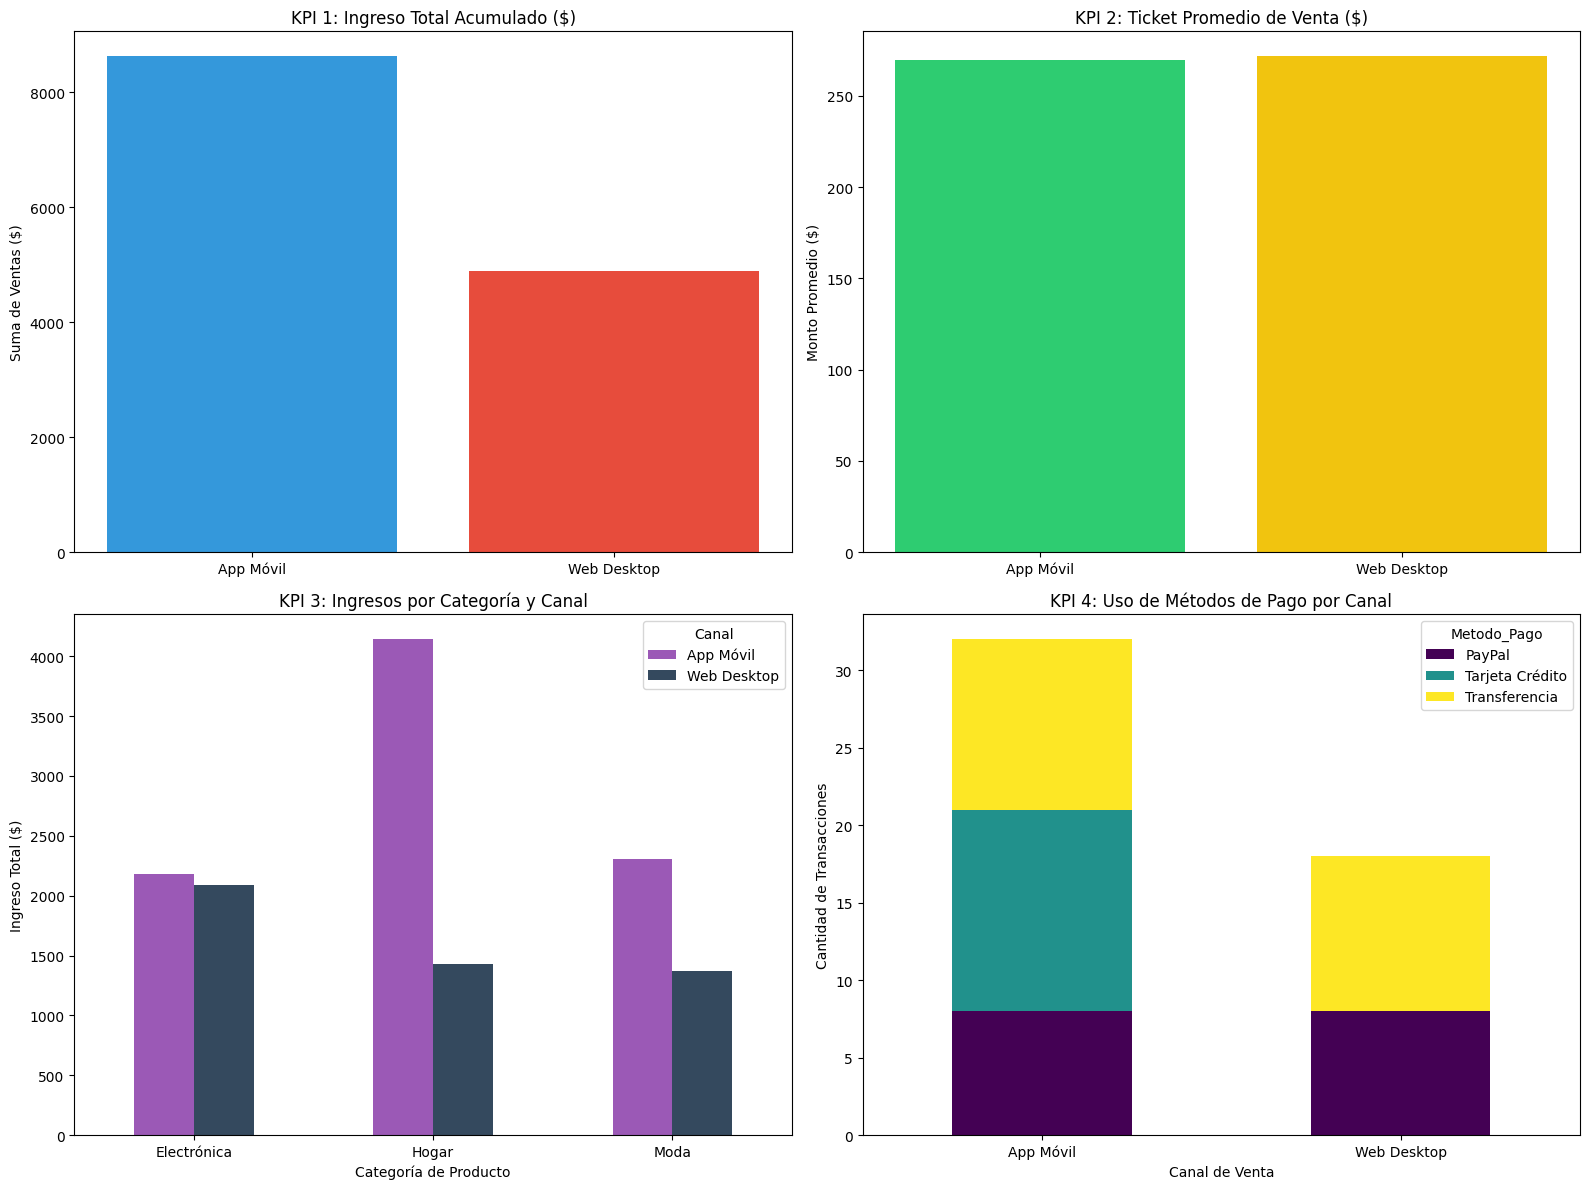

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- KPI 1: Ingreso Total por Canal ---
kpi1_total = df.groupby('Canal')['Total_Venta'].sum()
axes[0, 0].bar(kpi1_total.index, kpi1_total.values, color=['#3498db', '#e74c3c'])
axes[0, 0].set_title('KPI 1: Ingreso Total Acumulado ($)')
axes[0, 0].set_ylabel('Suma de Ventas ($)')

# --- KPI 2: Ticket Promedio por Canal ---
kpi2_promedio = df.groupby('Canal')['Total_Venta'].mean()
axes[0, 1].bar(kpi2_promedio.index, kpi2_promedio.values, color=['#2ecc71', '#f1c40f'])
axes[0, 1].set_title('KPI 2: Ticket Promedio de Venta ($)')
axes[0, 1].set_ylabel('Monto Promedio ($)')

# --- KPI 3: Ingresos por Categoría cruzado por Canal ---
# Agrupamos por dos columnas y usamos unstack() para poder graficar barras juntas
kpi3_cat = df.groupby(['Categoria', 'Canal'])['Total_Venta'].sum().unstack()
kpi3_cat.plot(kind='bar', ax=axes[1, 0], color=['#9b59b6', '#34495e'])
axes[1, 0].set_title('KPI 3: Ingresos por Categoría y Canal')
axes[1, 0].set_ylabel('Ingreso Total ($)')
axes[1, 0].set_xlabel('Categoría de Producto')
axes[1, 0].tick_params(axis='x', rotation=0) # Para que los nombres de abajo no salgan virados

# --- KPI 4: Métodos de Pago por Canal ---
# Contamos cuántas transacciones hay por método de pago en cada canal
kpi4_pago = df.groupby(['Canal', 'Metodo_Pago']).size().unstack(fill_value=0)
kpi4_pago.plot(kind='bar', stacked=True, ax=axes[1, 1], colormap='viridis')
axes[1, 1].set_title('KPI 4: Uso de Métodos de Pago por Canal')
axes[1, 1].set_ylabel('Cantidad de Transacciones')
axes[1, 1].set_xlabel('Canal de Venta')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Parte 2: KPIs para E-Commerce

Para esta parte vamos a utilizar los datos qu se encuentran en el repositorio en `/data/ecommerce.zip`

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('../data/ecommerce.zip')
data

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0


### 1. KPIs de Gestión de Logística y Operaciones (Shipment & Warehouse)

Permiten medir la eficiencia en la distribución de los productos electrónicos.

1.1. **Costo Promedio de Envío por Modo de Transporte (Mode of Shipment):** Ayuda a evaluar qué canales (Barco, Avión, Carretera) representan un mayor impacto financiero en relación con el peso del producto.

1.2. **Volumen de Ocupación por Bloque de Bodega (Warehouse Block):** Porcentaje o cantidad total de productos/peso administrados en cada bloque (A, B, C, D, E) para entender la carga operativa de la infraestructura.

1.3. **Peso Promedio del Producto por Modo de Envío:** Para analizar si se está optimizando la logística (ej. si los productos más pesados se están enviando por barco o si se está gastando de más enviándolos por avión).

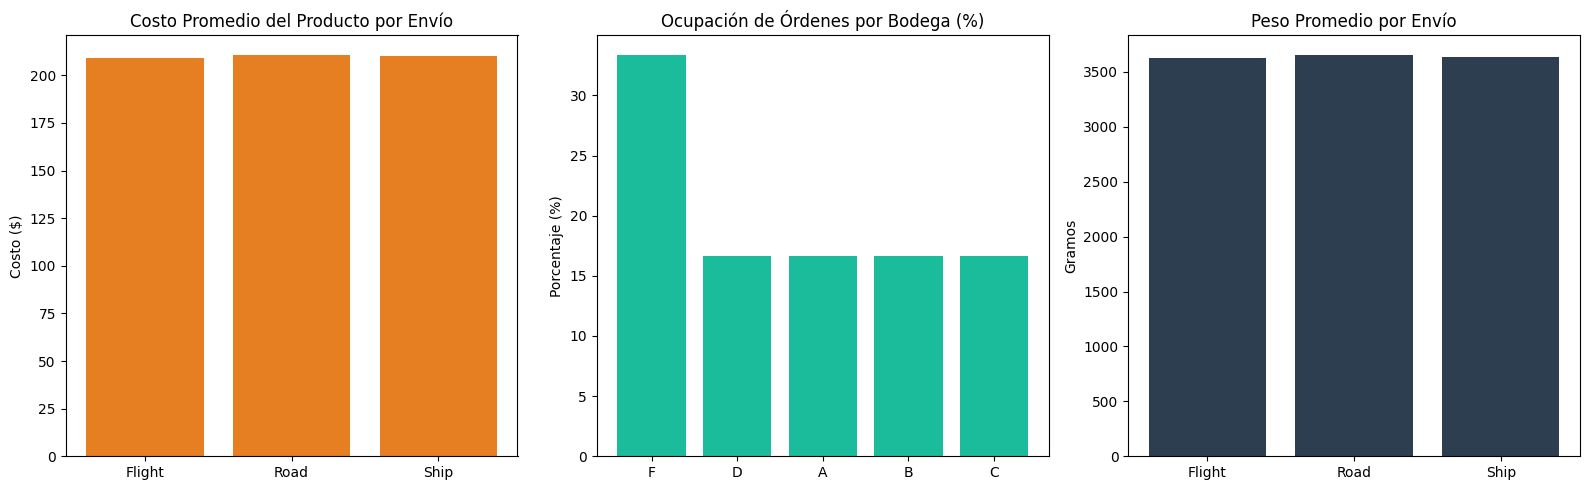

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Carga de datos reales
df_real = pd.read_csv('../data/ecommerce.zip')

# Dashboard Logístico
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df_envio = df_real.groupby('Mode_of_Shipment')['Cost_of_the_Product'].mean()
axes[0].bar(df_envio.index, df_envio.values, color='#e67e22')
axes[0].set_title('Costo Promedio del Producto por Envío')
axes[0].set_ylabel('Costo ($)')

df_bodega = df_real['Warehouse_block'].value_counts(normalize=True) * 100
axes[1].bar(df_bodega.index, df_bodega.values, color='#1abc9c')
axes[1].set_title('Ocupación de Órdenes por Bodega (%)')
axes[1].set_ylabel('Porcentaje (%)')

df_peso = df_real.groupby('Mode_of_Shipment')['Weight_in_gms'].mean()
axes[2].bar(df_peso.index, df_peso.values, color='#2c3e50')
axes[2].set_title('Peso Promedio por Envío')
axes[2].set_ylabel('Gramos')

plt.tight_layout()
plt.show()

### 2. KPIs de Gestión Comercial y Financiera (Sales & Revenue)

Enfocados en el rendimiento del dinero, los descuentos y la estrategia de precios.

2.1. **Ingreso Total Bruto y Costo Promedio del Producto:** Suma y promedio de la variable `Cost of the product` para entender el ticket promedio de la tienda de electrónica.

2.2. **Porcentaje de Descuento Promedio Otorgado:** Evaluar el impacto de la estrategia de promociones (`Discount offered`) y si los descuentos altos realmente correlacionan con clientes de mayor prioridad o compras previas.

2.3. **Margen Teórico Relativo por Importancia del Producto:** Cruzar `Product importance` (Low, Medium, High) con el costo para ver si los productos catalogados como "alta importancia" son también los más costosos o los que reciben más descuentos.

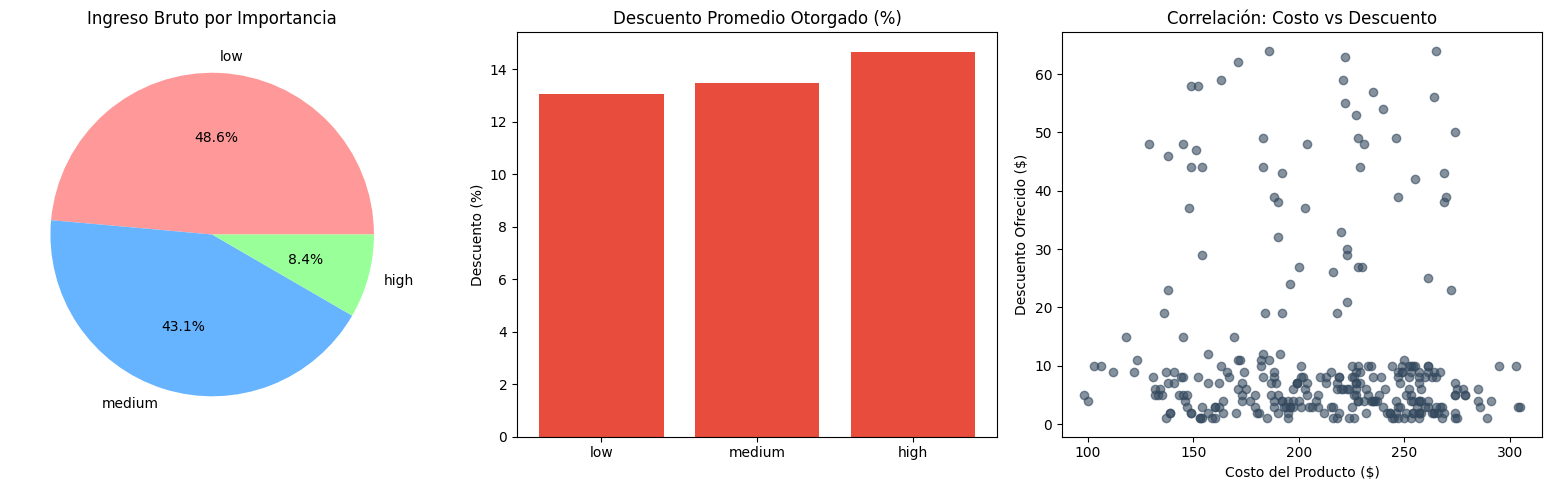

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df_ingresos = df_real.groupby('Product_importance')['Cost_of_the_Product'].sum().reindex(['low', 'medium', 'high'])
axes[0].pie(df_ingresos.values, labels=df_ingresos.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
axes[0].set_title('Ingreso Bruto por Importancia')

df_desc = df_real.groupby('Product_importance')['Discount_offered'].mean().reindex(['low', 'medium', 'high'])
axes[1].bar(df_desc.index, df_desc.values, color='#e74c3c')
axes[1].set_title('Descuento Promedio Otorgado (%)')
axes[1].set_ylabel('Descuento (%)')

muestra = df_real.sample(300, random_state=42)
axes[2].scatter(muestra['Cost_of_the_Product'], muestra['Discount_offered'], alpha=0.6, color='#34495e')
axes[2].set_title('Correlación: Costo vs Descuento')
axes[2].set_xlabel('Costo del Producto ($)')
axes[2].set_ylabel('Descuento Ofrecido ($)')

plt.tight_layout()
plt.show()

### 3. KPIs de Experiencia y Fidelización del Cliente (Customer Experience - CX)

Diseñados para evaluar la satisfacción y la carga de soporte post-venta.

3.1. **Índice de Satisfacción del Cliente (CSAT) Promedio:** El promedio de la variable `Customer rating` (escala 1 a 5). Se puede segmentar por género o por bloque de bodega para ver si hay anomalías.

3.2. **Tasa de Retención / Clientes Recurrentes:** Analizar la distribución de `Prior purchases` para determinar qué porcentaje de la base de datos son clientes nuevos (0-1 compras previas) vs. clientes fidelizados (2 o más compras).

3.3. **Carga de Soporte por Cliente (Customer Care Calls):** Promedio de llamadas de consulta realizadas. Permite analizar si a mayor costo del producto o menores calificaciones, aumentan las llamadas de reclamo.

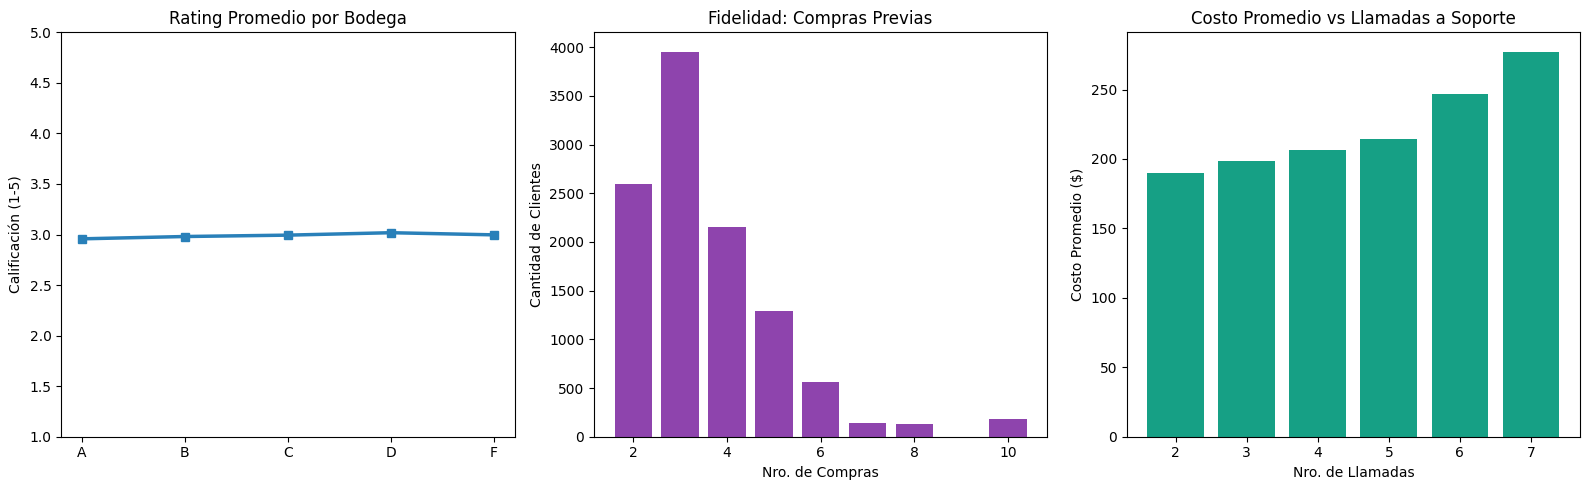

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df_csat_b = df_real.groupby('Warehouse_block')['Customer_rating'].mean()
axes[0].plot(df_csat_b.index, df_csat_b.values, marker='s', color='#2980b9', linewidth=2.5)
axes[0].set_title('Rating Promedio por Bodega')
axes[0].set_ylabel('Calificación (1-5)')
axes[0].set_ylim(1, 5)

df_compras = df_real['Prior_purchases'].value_counts().sort_index()
axes[1].bar(df_compras.index, df_compras.values, color='#8e44ad')
axes[1].set_title('Fidelidad: Compras Previas')
axes[1].set_xlabel('Nro. de Compras')
axes[1].set_ylabel('Cantidad de Clientes')

df_llamadas = df_real.groupby('Customer_care_calls')['Cost_of_the_Product'].mean()
axes[2].bar(df_llamadas.index, df_llamadas.values, color='#16a085')
axes[2].set_title('Costo Promedio vs Llamadas a Soporte')
axes[2].set_xlabel('Nro. de Llamadas')
axes[2].set_ylabel('Costo Promedio ($)')

plt.tight_layout()
plt.show()